# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import parismc
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



# Initialization

In [2]:
# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.


In [3]:
print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

Creating GravWaveAnalysis class...


In [4]:
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5

In [5]:
np.cos(qS)

0.8775825618903728

In [6]:
print("Generate data...")
data = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)

Generate data...


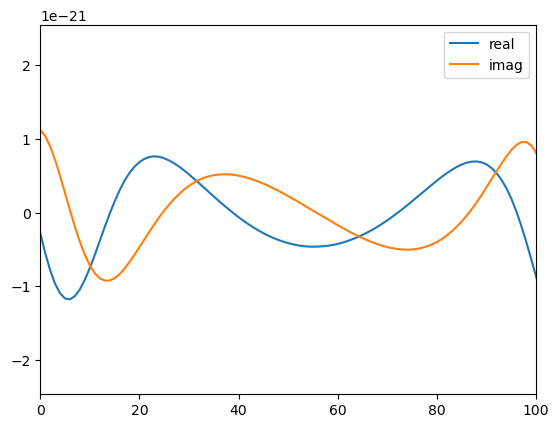

In [7]:
plt.plot(data.get().real, label='real')
plt.plot(data.get().imag, label='imag')
plt.xlim(0,100)
plt.legend(loc='upper right')
plt.show()

In [8]:
data_f = gwf.freq_wave(data)
gwf.SNR(data_f)

array(107.43944631)

# Likelihood, prior

In [9]:
def loglike(params):

    params = np.asarray(params)

    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a, p0, e0, dist, cosqS, phiS, Phi_phi0, Phi_r0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2
        qS = np.arccos(cosqS)
        phiK = phiS + np.pi/3

        htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
        

        res = data - htemp
        res_f = gwf.freq_wave(res)
        inner_res = gwf.inner(res_f, res_f)
        log_likes[i] = -0.5 * inner_res

    return log_likes

In [10]:
def prior_transform(u):

    # WIDER using diag of cov
    logm1lim = [5.999755966003094, 6.000244033996906]
    logm2lim = [1.4769870513061485, 1.4772554581331763]
    alim = [0.6995637359288023, 0.7004362640711976]
    p0lim = [7.497572969128289, 7.502427030871711]
    e0lim = [0.39989407441630453, 0.4001059255836955]
    distlim = [0.4671238045922167, 0.5328761954077833]
    cosqSlim = [0.8175373164938913, 0.9376278072868542]
    phiSlim = [0.8907980491383655, 1.1092019508616344]
    Phiphilim = [0.2971011746225549, 0.5028988253774451]
    Phirlim = [0.4374942669461721, 0.5625057330538279]


    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    # dist 
    transformed[:, 5] = (distlim[1] - distlim[0]) * u[:, 5] + distlim[0]

    # Uniform in cosqS 

    # qS
    transformed[:, 6] = (cosqSlim[1] - cosqSlim[0]) * u[:, 6] + cosqSlim[0]

    # phiS
    transformed[:, 7] = (phiSlim[1] - phiSlim[0]) * u[:, 7] + phiSlim[0]

    # Phi_phi0
    transformed[:, 8] = (Phiphilim[1] - Phiphilim[0]) * u[:, 8] + Phiphilim[0]

    # Phi_r0
    transformed[:, 9] = (Phirlim[1] - Phirlim[0]) * u[:, 9] + Phirlim[0]

    
    return transformed

In [12]:
def inverse_prior_transform(x):
    # WIDER using diag of cov
    logm1lim = [5.999755966003094, 6.000244033996906]
    logm2lim = [1.4769870513061485, 1.4772554581331763]
    alim = [0.6995637359288023, 0.7004362640711976]
    p0lim = [7.497572969128289, 7.502427030871711]
    e0lim = [0.39989407441630453, 0.4001059255836955]
    distlim = [0.4671238045922167, 0.5328761954077833]
    cosqSlim = [0.8175373164938913, 0.9376278072868542]
    phiSlim = [0.8907980491383655, 1.1092019508616344]
    Phiphilim = [0.2971011746225549, 0.5028988253774451]
    Phirlim = [0.4374942669461721, 0.5625057330538279]

    u = np.zeros_like(x)
    
    # Inverse of: transformed = (max - min) * u + min
    # Solution: u = (transformed - min) / (max - min)
    
    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (x[:, 5] - distlim[0]) / (distlim[1] - distlim[0])
    u[:, 6] = (x[:, 6] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 7] = (x[:, 7] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    u[:, 8] = (x[:, 8] - Phiphilim[0]) / (Phiphilim[1] - Phiphilim[0])
    u[:, 9] = (x[:, 9] - Phirlim[0]) / (Phirlim[1] - Phirlim[0])
    
    return u

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, Phi_phi0, Phi_r0]


In [15]:
external_lhs_points = inverse_prior_transform(np.array([param_true]))
external_lhs_points

array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]])

In [16]:
loglike(prior_transform(external_lhs_points))

array([-2.23224141e-18])

# Sampling

In [19]:
print('Done setting up log-likelihood and prior.')
print('Setting up ParisMC sampler...')
config = parismc.SamplerConfig(
    merge_confidence=0.9,          # Coverage prob → Mahalanobis merge radius R_m (higher is more permissive)
    alpha=10000,                    # Use recent samples for weighting. 
    trail_size=int(1e3),          # Maximum trials per iteration
    boundary_limiting=True,        # Enable boundary constraints
    use_beta=True,                # Use beta correction for boundaries
    integral_num=int(1e5),        # MC samples for beta estimation
    gamma=500,                    # Covariance update frequency
    exclude_scale_z=10,       # No exclusion based on weights
    use_pool=False,               # Set to True for multiprocessing
    n_pool=4                      # Number of processes (if use_pool=True)
)

Done setting up log-likelihood and prior.
Setting up ParisMC sampler...


In [20]:
print('Done setting up ParisMC sampler.')
print('Setting up initial covariance matrix...')
# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

import pickle
with open('cov_matrix_new.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)

Done setting up ParisMC sampler.
Setting up initial covariance matrix...


In [ ]:
ndim = 10
n_seed = 1

In [ ]:
init_cov_list = [cov_matrix for _ in range(n_seed)]


In [ ]:
print('Done setting up initial covariance matrix.')
print('Initializing sampler...')
sampler = parismc.Sampler(
    ndim=ndim, 
    n_seed=n_seed,
    log_density_func=loglike,
    init_cov_list=init_cov_list,
    prior_transform=prior_transform,
    config=config
)
print('Done initializing sampler.')


In [ ]:
print('Preparing LHS samples...')
sampler.prepare_lhs_samples(lhs_num=int(100), batch_size=10)
print('Done preparing LHS samples.')


In [ ]:
sampling_list = sampler.searched_log_densities_list[0]
inf_list = sampling_list[~np.isfinite(sampling_list)]
len(inf_list)

# Visualization

In [45]:
# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

In [46]:
sampler = parismc.Sampler.load_state('./paris_likelihoodtest_10s/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)

/nfs/home/svu/e1498138/localgit/parismc/parismc/sampler.py:700: RuntimeWarning: overflow encountered in exp
  weights = np.exp(self.searched_log_densities_list[j][:element_num] - self.loglike_normalization)


In [47]:
sampler.prior_transform(np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]))


array([[5.99918655, 1.47667391, 0.69854579, 7.4919099 , 0.39964691,
        0.39041268, 0.67743174, 0.6359935 , 0.05700392, 0.29164756]])

In [48]:
sampler.prior_transform(np.array([[1.,1.,1.,1.,1.,1.,1.,1.,1.,1.]]))

array([[6.00081345, 1.4775686 , 0.70145421, 7.5080901 , 0.40035309,
        0.60958732, 1.        , 1.3640065 , 0.74299608, 0.70835244]])

In [49]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, Phi_phi0, Phi_r0]

In [50]:
sampler.searched_log_densities_list[0][~np.isfinite(sampler.searched_log_densities_list[0])]

array([-inf, -inf, -inf, -inf])

In [52]:
# Create mask for finite values in both samples and weights
mask = np.isfinite(samples).all(axis=1) & np.isfinite(weights)

# Apply mask
samples_clean = samples[mask]
weights_clean = weights[mask]

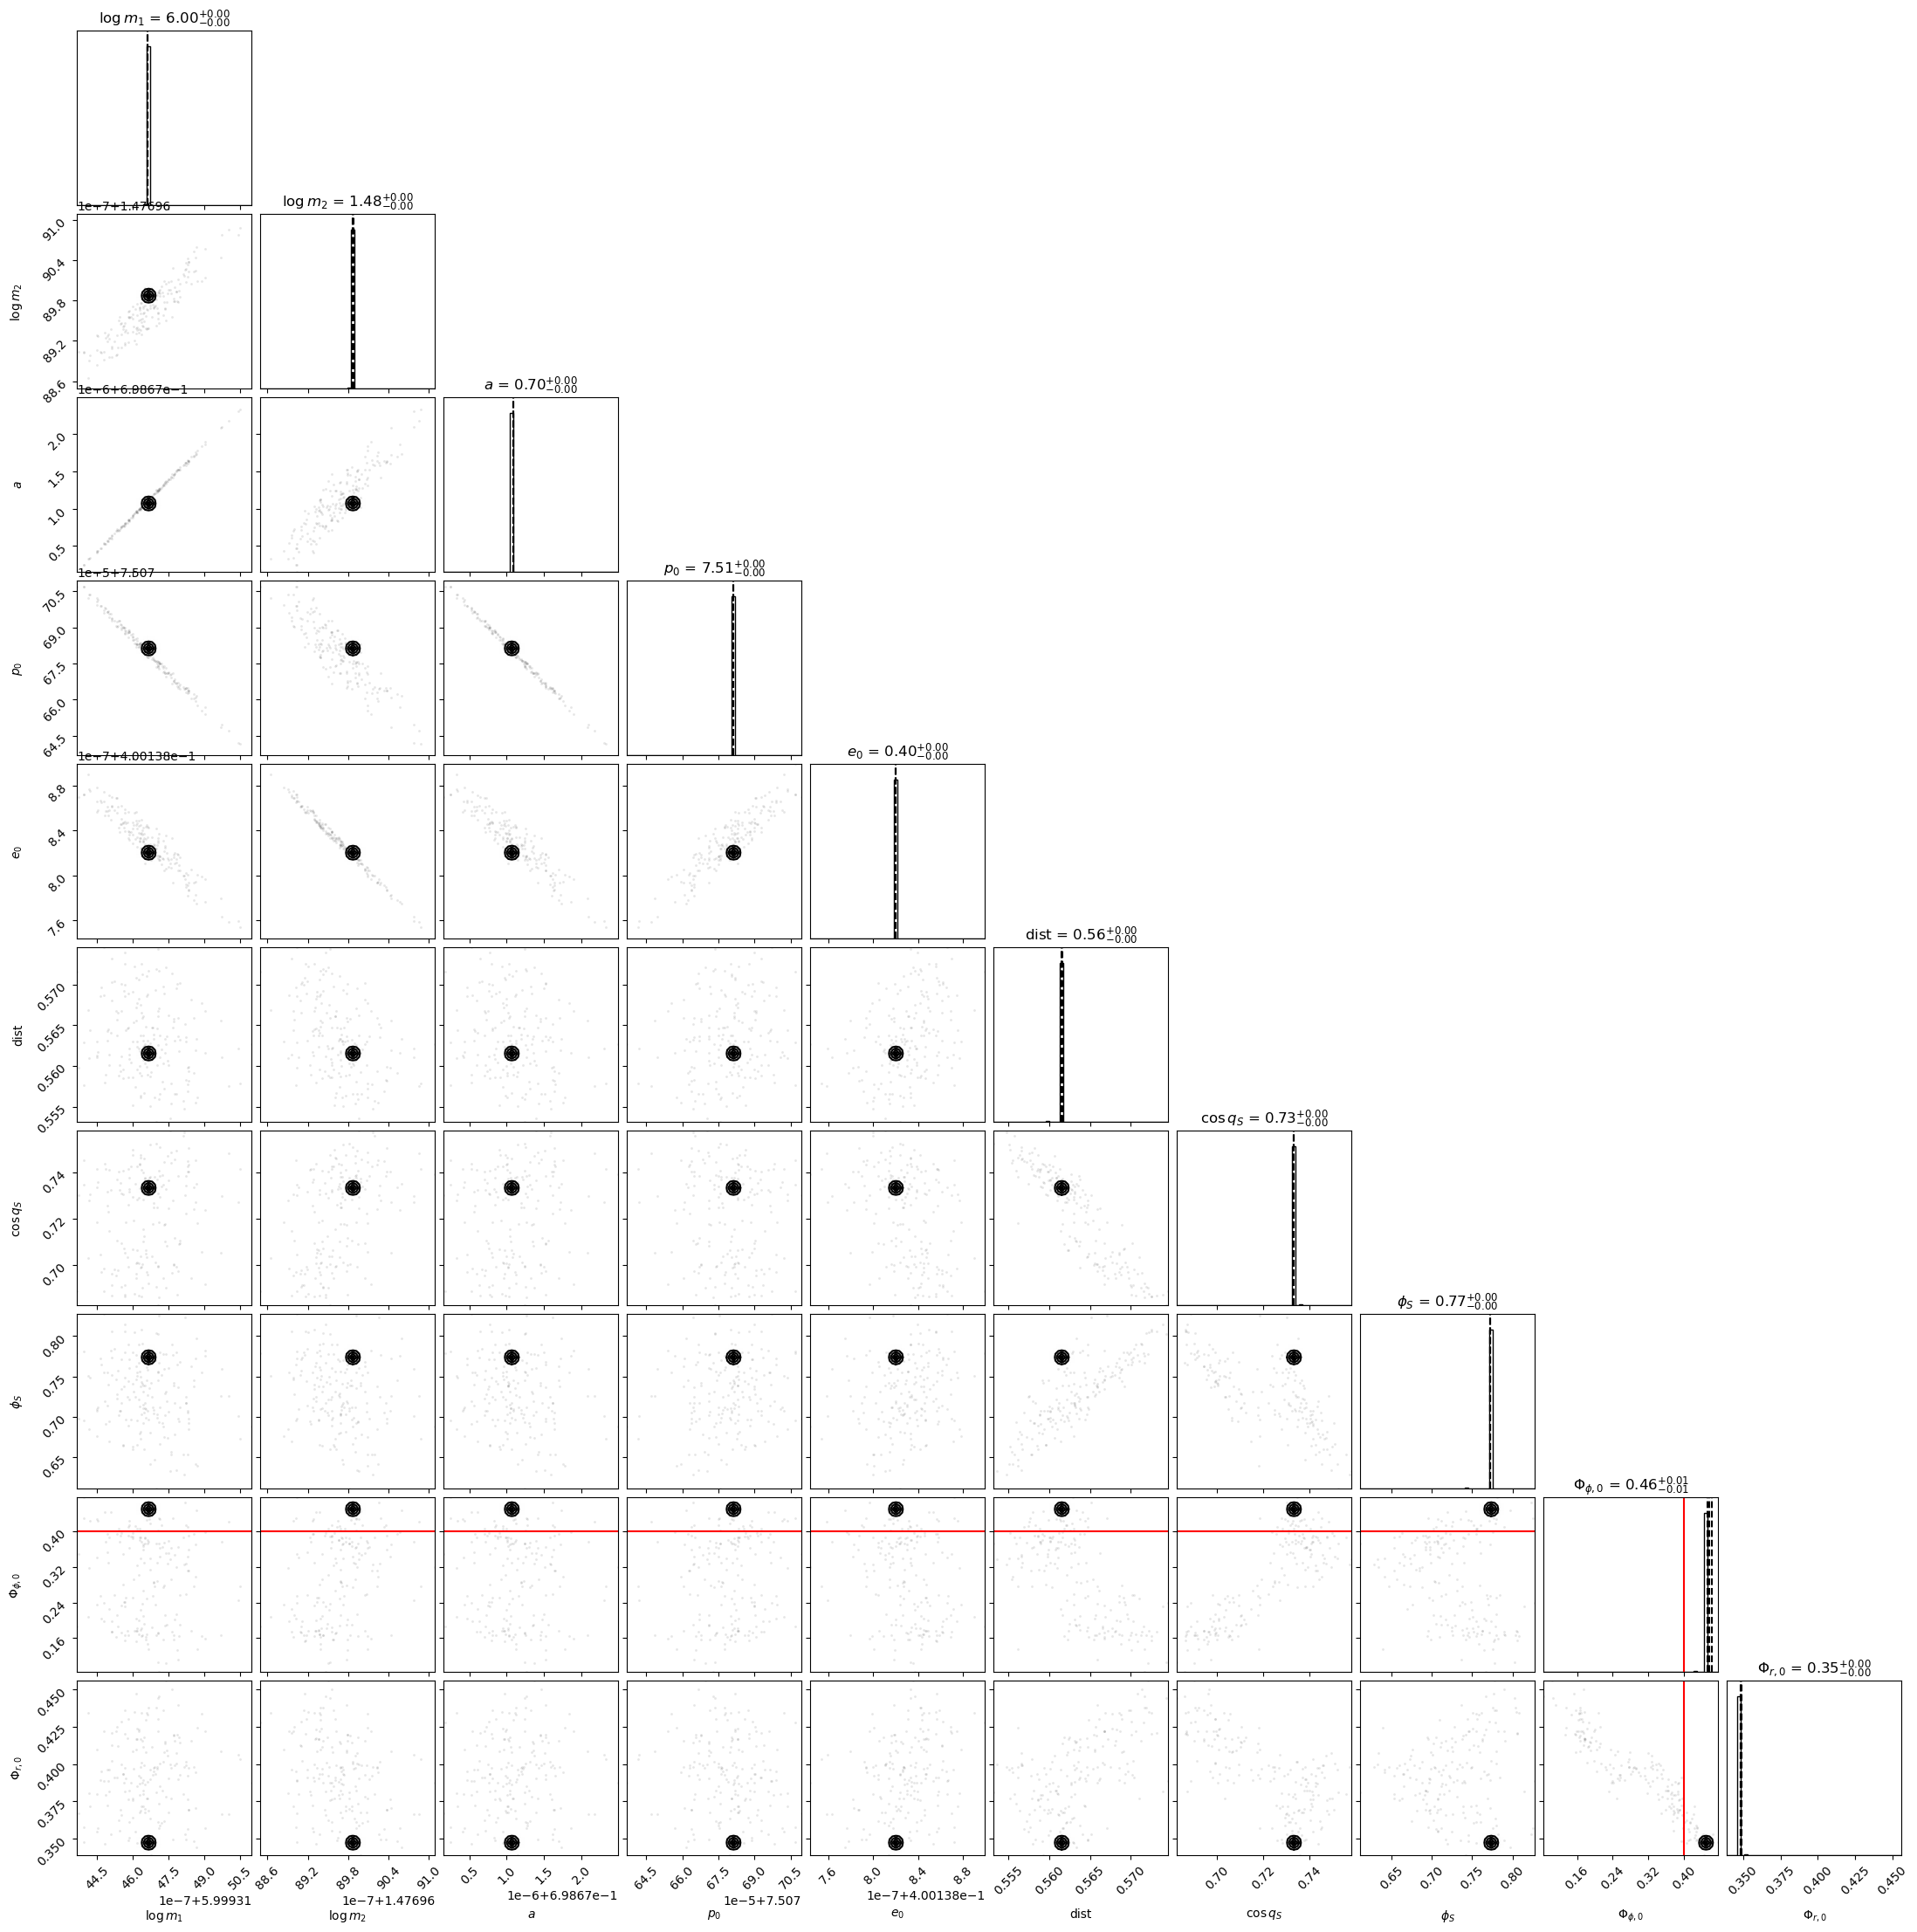

In [53]:
# try corner
import corner
labels = [r'$\log{m_1}$', r'$\log{m_2}$',r'$a$',r'$p_0$',r'$e_0$',r'dist',r'$\cos{q_S}$', r'$\phi_S$',
        r'$\Phi_{\phi,0}$', r'$\Phi_{r,0}$']

fig = corner.corner(
    samples_clean,
    weights=weights_clean,
    labels=labels,
    truths=param_true,
    truth_color='red',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma and median
    smooth=True,
    bins=50
)

In [54]:
import pickle
with open('cov_matrix_new.pkl', 'rb') as f:
    cov_mat = pickle.load(f)

# with open('ns_likelihoodtest.pkl', 'rb') as f:
#     dres = pickle.load(f)

# dynesty_samples = dres.samples
# dynesty_weights = dres.importance_weights()


In [55]:
len(sampler.searched_log_densities_list[0][~np.isfinite(sampler.searched_log_densities_list[0])])

4

In [56]:
from scipy.stats import multivariate_normal

n_fisher_samples = 10000
fisher_samples = multivariate_normal.rvs(
    mean=param_true, 
    cov=cov_mat,     
    size=n_fisher_samples
)

In [57]:
# param_ranges = [
#     (5.999755966003094, 6.000244033996906),      # logm1
#     (1.4769870513061485, 1.4772554581331763),    # logm2
#     (0.6995637359288023, 0.7004362640711976),    # a
#     (7.497572969128289, 7.502427030871711),      # p0
#     (0.39989407441630453, 0.4001059255836955),   # e0
#     (0.4671238045922167, 0.5328761954077833),    # dist
#     (0.8175373164938913, 0.9376278072868542),    # cosqS
#     (0.8907980491383655, 1.1092019508616344),    # phiS
#     (0.2971011746225549, 0.5028988253774451),    # Phiphi
#     (0.4374942669461721, 0.5625057330538279)     # Phir
# ]

# param_ranges = [
#     (5.999999946489075, 6.000000053510925),
#     (1.477120956636667, 1.4771215528026578),
#     (0.6999993767274207, 0.7000006232725792), #[0.6999993767274225, 0.7000006232725774]
#     (7.499999437916994, 7.500000562083006),
#     (0.39999977170770384, 0.4000002282922962),
#     (0.4860386493238116, 0.5139613506761884),
#     (0.8702397352956238, 0.8849253884851217),
#     (0.9855342921219667, 1.0144657078780333),
#     (0.38728579253388856, 0.4127142074661115),
#     (0.484683807978082, 0.515316192021918)
# ]

param_ranges = [
    (5.999186553343646, 6.000813446656354),      # logm1
    (1.4766739100079498, 1.477568599431375),     # logm2
    (0.6985457864293411, 0.7014542135706588),    # a
    (7.491909897094295, 7.508090102905705),      # p0
    (0.399646914721015, 0.40035308527898505),    # e0
    (0.39041268197405565, 0.6095873180259443),   # dist
    (0.677431743902101, 1.0),                    # cosqS
    (0.6359934971278849, 1.3640065028721151),    # phiS
    (0.05700391540851629, 0.7429960845914838),   # Phiphi
    (0.2916475564872404, 0.7083524435127596)     # Phir
]

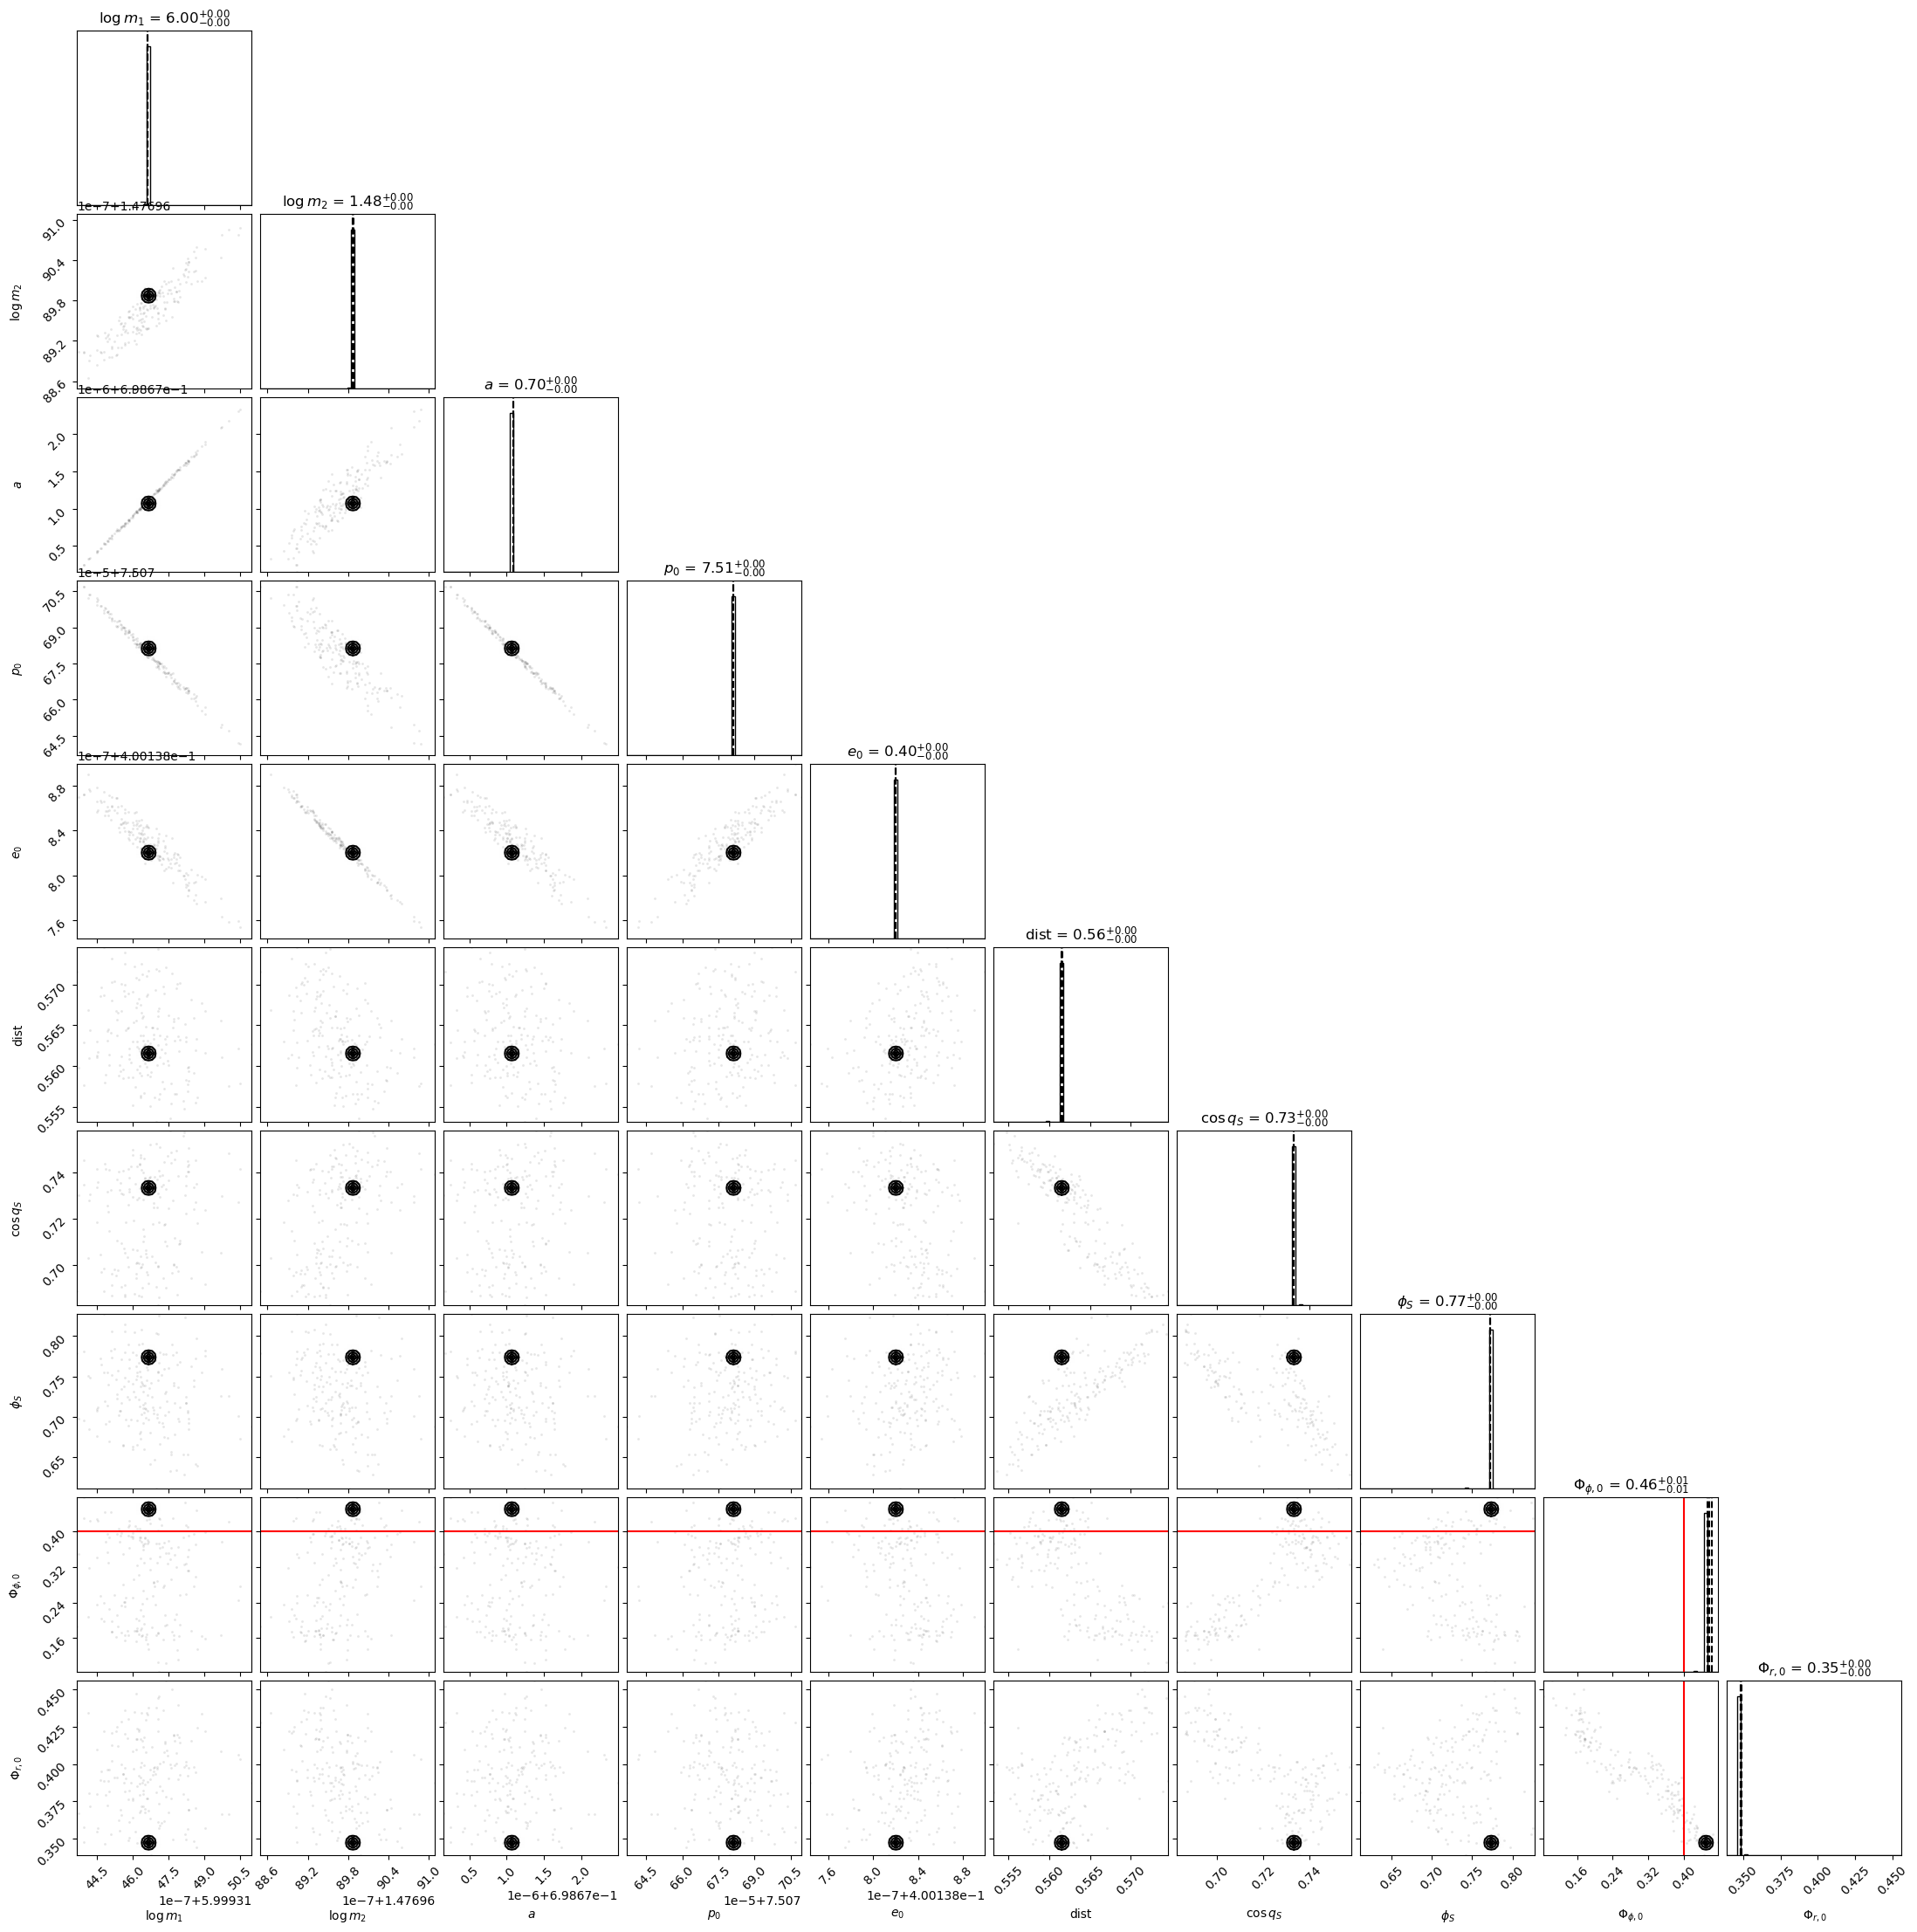

In [58]:


fig = corner.corner(
    samples_clean,
    weights=weights_clean,
    labels=labels,
    truths=param_true,
    truth_color='red',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],  # 1-sigma and median
    smooth=True,
    bins=50,
    ranges = param_ranges,
)

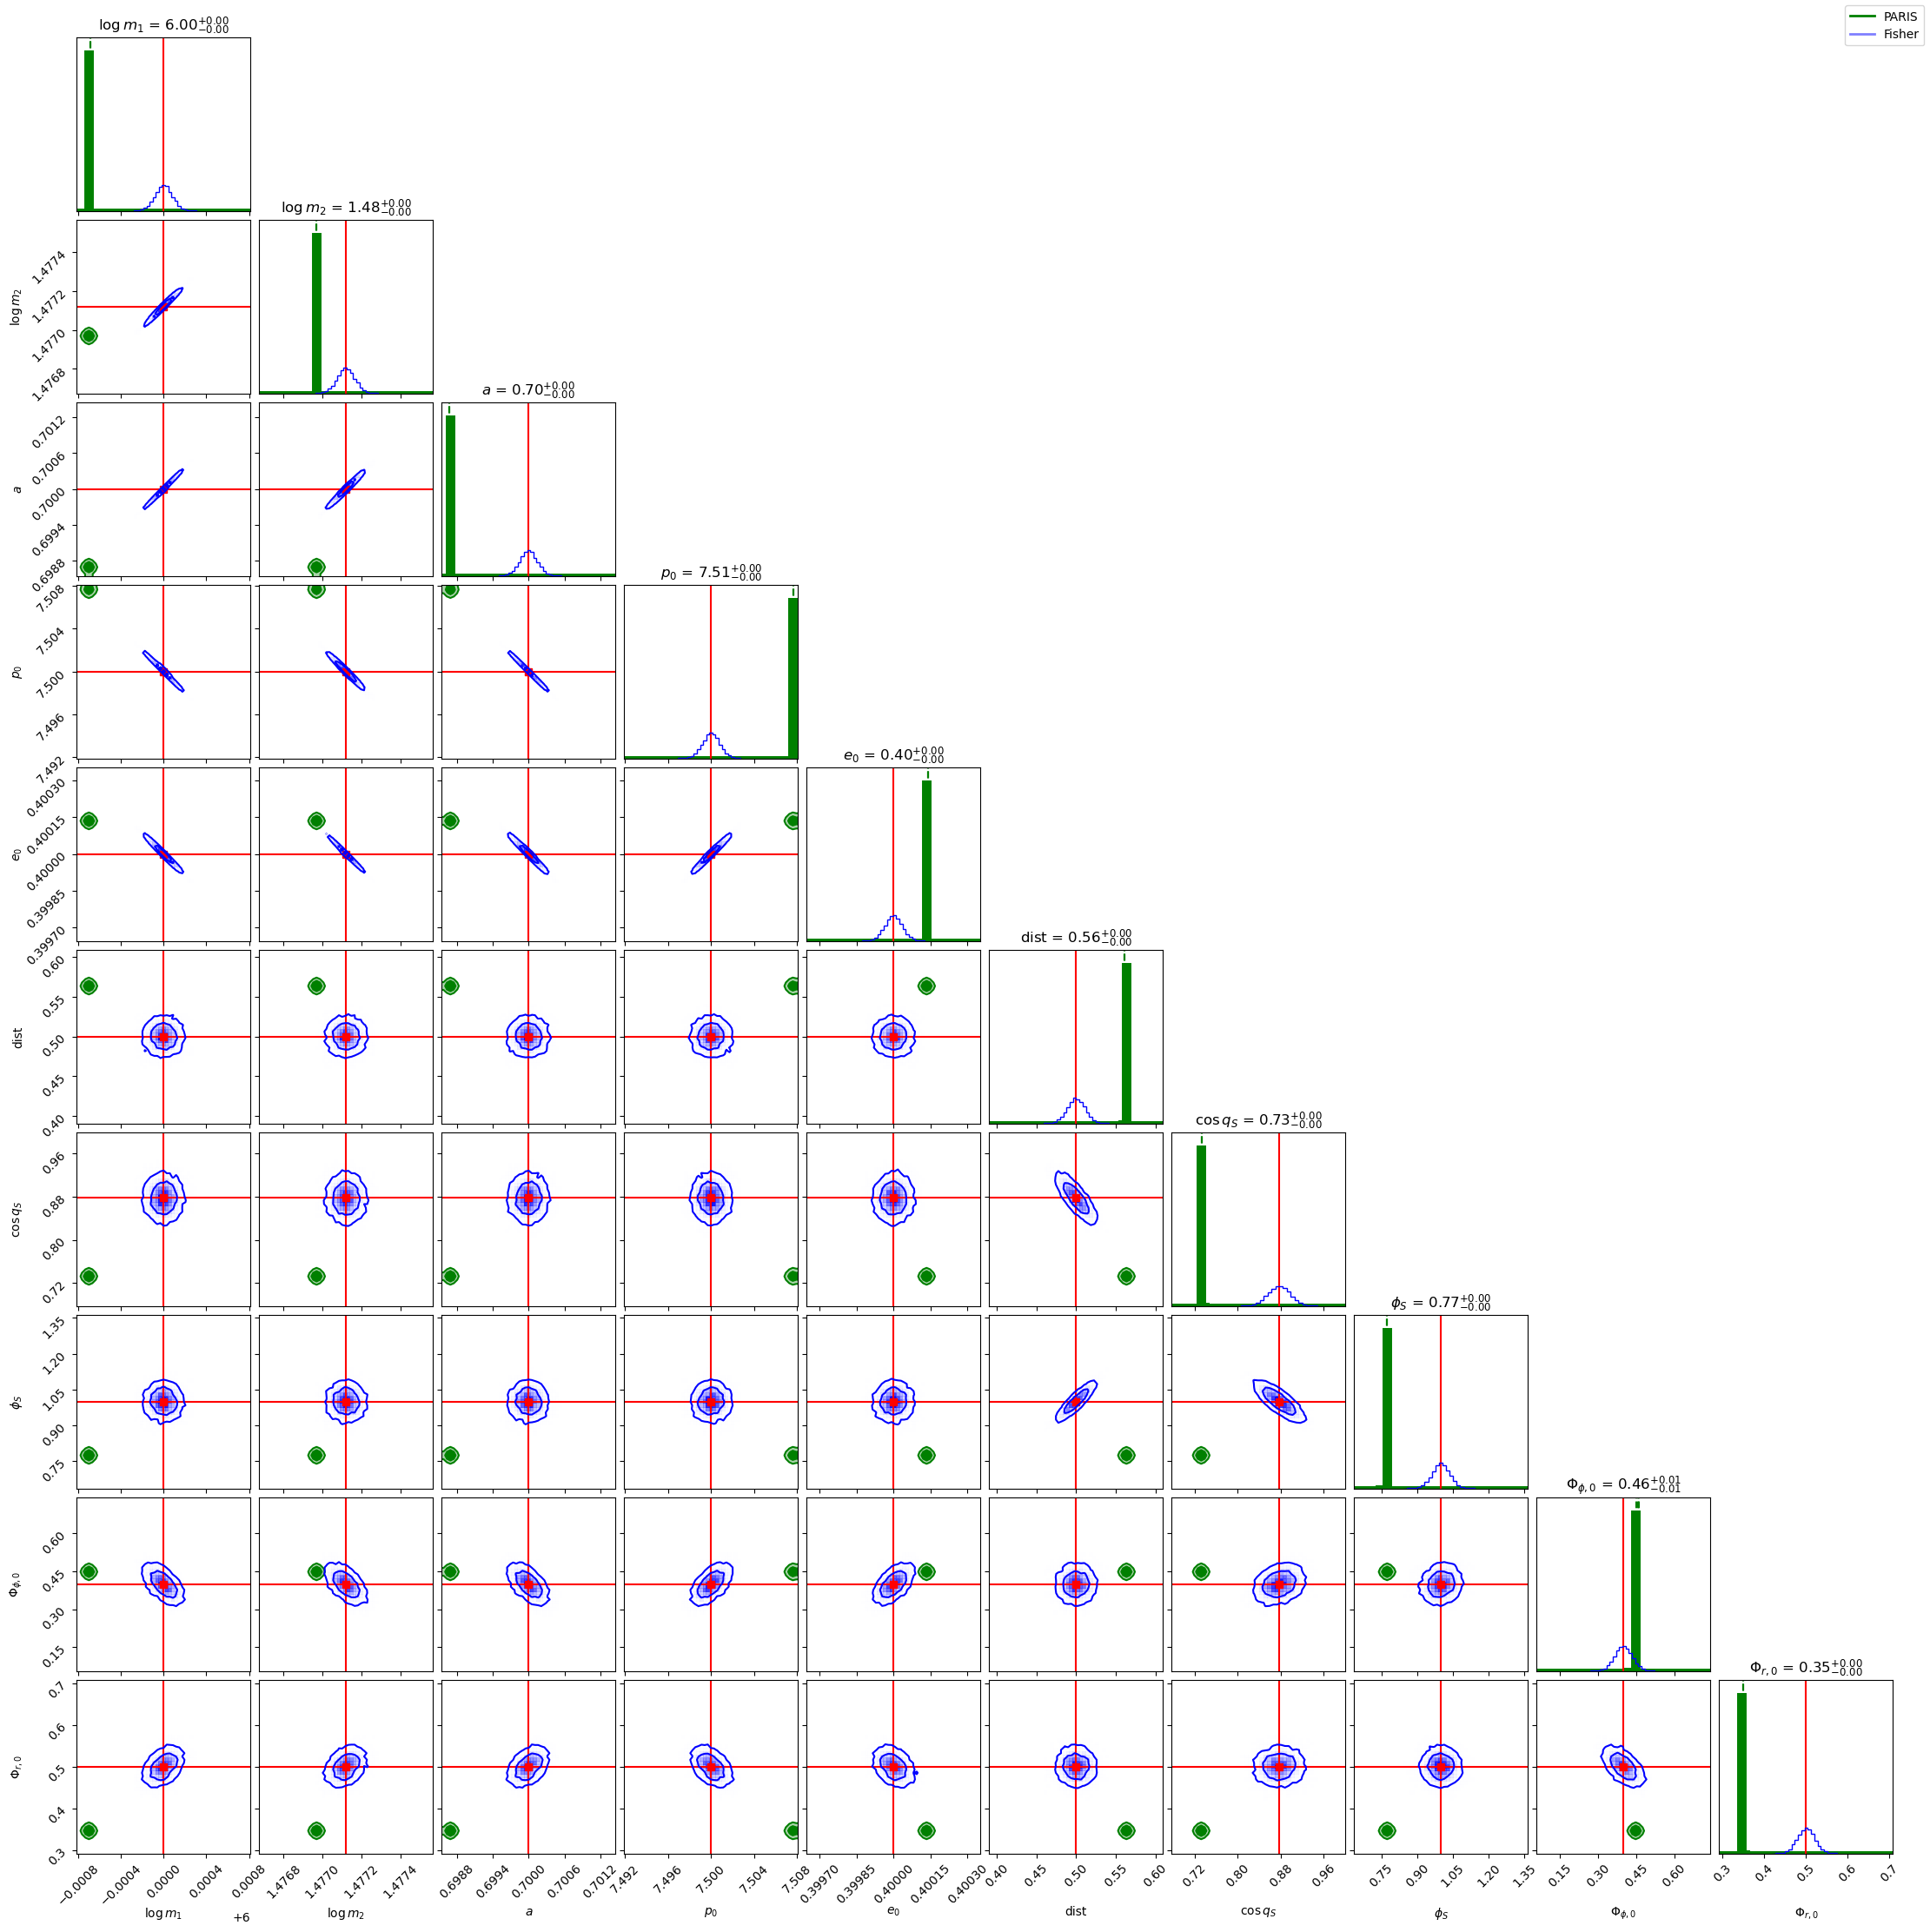

In [59]:
fig = corner.corner(
    samples_clean,
    weights=weights_clean,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=50,
    plot_datapoints=False,
    plot_density= True,
    levels=[0.68, 0.95],
    hist_kwargs={"density": True, 'linewidth': 5},
    linewidth=5,
    fill_contours=True,
    range = param_ranges
)

# Overlay Fisher ellipses
corner.corner(
    fisher_samples,
    fig=fig,
    color='blue',
    plot_datapoints=False,
    plot_density=True,
    levels=[0.68, 0.95],
    alpha=0.5,
    hist_kwargs={"density": True},
    # range = param_ranges
)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='PARIS'),
    # Line2D([0], [0], color='red', lw=2, label='Dynesty'),
    Line2D([0], [0], color='blue', lw=2, label='Fisher', alpha=0.5)
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)

In [68]:
sigmas = []
for i in range(10):
    sigma_i = np.sqrt(cov_mat[i, i])
    sigmas.append(sigma_i)

In [69]:
len(param_true)

10

In [70]:
param_range = []
for i in range(10):
    param_min = param_true[i] - 2.5*sigmas[i]
    param_max = param_true[i] + 2.5*sigmas[i]
    param_range.append((param_min, param_max))

In [71]:
param_range

[(5.999796638335912, 6.000203361664088),
 (1.4770094185417342, 1.4772330908975906),
 (0.6996364466073353, 0.7003635533926647),
 (7.497977474273574, 7.502022525726426),
 (0.39991172868025376, 0.4000882713197463),
 (0.4726031704935139, 0.527396829506486),
 (0.8275448573933049, 0.9276202663874407),
 (0.9089983742819713, 1.0910016257180288),
 (0.3142509788521291, 0.48574902114787094),
 (0.4479118891218101, 0.5520881108781899)]

In [20]:
cov_mat

array([[ 6.61695463e-09,  3.60293879e-09,  1.18258744e-08,
        -6.57747694e-08, -2.84232041e-09,  1.32478263e-08,
        -1.41970506e-08, -1.61055894e-10, -1.53896783e-06,
         7.05159260e-07],
       [ 3.60293879e-09,  2.00117291e-09,  6.42177140e-09,
        -3.56535332e-08, -1.57857274e-09,  7.29060311e-09,
        -7.79541413e-09, -1.56619007e-10, -8.03365906e-07,
         3.03049865e-07],
       [ 1.18258744e-08,  6.42177140e-09,  2.11473711e-08,
        -1.17632656e-07, -5.06384246e-09,  2.36174590e-08,
        -2.57978466e-08, -6.78384677e-10, -2.73308181e-06,
         1.27654857e-06],
       [-6.57747694e-08, -3.56535332e-08, -1.17632656e-07,
         6.54497650e-07,  2.81224120e-08, -1.31281493e-07,
         1.41508423e-07,  2.19008240e-09,  1.53758656e-05,
        -7.30994176e-06],
       [-2.84232041e-09, -1.57857274e-09, -5.06384246e-09,
         2.81224120e-08,  1.24669214e-09, -5.76123674e-09,
         5.91592254e-09, -8.01824406e-11,  6.53336756e-07,
        -2.

In [21]:
params = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), phiS, Phi_phi0, Phi_r0]
params_names = ['logm1','logm2','a','p0','e0','dist','cosqS','phiS','Phi_phi0','Phi_r0']

In [22]:
Fisher = np.linalg.inv(cov_mat)

In [24]:
sigmas = []
for i in range(len(params_names)):
    # sigmas.append(1/np.sqrt(Fisher[i, i]))
    sigmas.append(np.sqrt(cov_mat[i, i]))

In [26]:
priors = []
for i in range(len(params)):
    print(f"== Parameter: {params_names[i]}, Sigma: {sigmas[i]}")
    # set 3sig prior range
    prior_min = params[i] - 10*sigmas[i]
    prior_max = params[i] + 10*sigmas[i]
    print(f"10-sigma prior range: [{prior_min}, {prior_max}]")
    priors.append([prior_min, prior_max])

== Parameter: logm1, Sigma: 8.134466563536008e-05
10-sigma prior range: [5.999186553343646, 6.000813446656354]
== Parameter: logm2, Sigma: 4.4734471171261874e-05
10-sigma prior range: [1.4766739100079498, 1.477568599431375]
== Parameter: a, Sigma: 0.0001454213570658854
10-sigma prior range: [0.6985457864293411, 0.7014542135706588]
== Parameter: p0, Sigma: 0.0008090102905705506
10-sigma prior range: [7.491909897094295, 7.508090102905705]
== Parameter: e0, Sigma: 3.530852789850132e-05
10-sigma prior range: [0.399646914721015, 0.40035308527898505]
== Parameter: dist, Sigma: 0.010958731802594433
10-sigma prior range: [0.39041268197405565, 0.6095873180259443]
== Parameter: cosqS, Sigma: 0.02001508179882717
10-sigma prior range: [0.677431743902101, 1.0777333798786444]
== Parameter: phiS, Sigma: 0.036400650287211504
10-sigma prior range: [0.6359934971278849, 1.3640065028721151]
== Parameter: Phi_phi0, Sigma: 0.034299608459148374
10-sigma prior range: [0.05700391540851629, 0.7429960845914838]


In [33]:
wave_params = {
    'logm1': np.log10(m1),
    'logm2': np.log10(m2),
    'a': a,
    'p0': p0,
    'e0': e0,
    'dist': dist,
    'cosqS': np.cos(qS),
    'phiS': phiS,
    'Phi_phi0': Phi_phi0,
    'Phi_r0': Phi_r0
}

In [34]:
params_names

['logm1',
 'logm2',
 'a',
 'p0',
 'e0',
 'dist',
 'cosqS',
 'phiS',
 'Phi_phi0',
 'Phi_r0']

(<Figure size 2000x2000 with 55 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='logm2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='a'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='p0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='e0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='dist'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='cosqS'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='phiS'>, <Axes: >, <Axes: >, <Ax

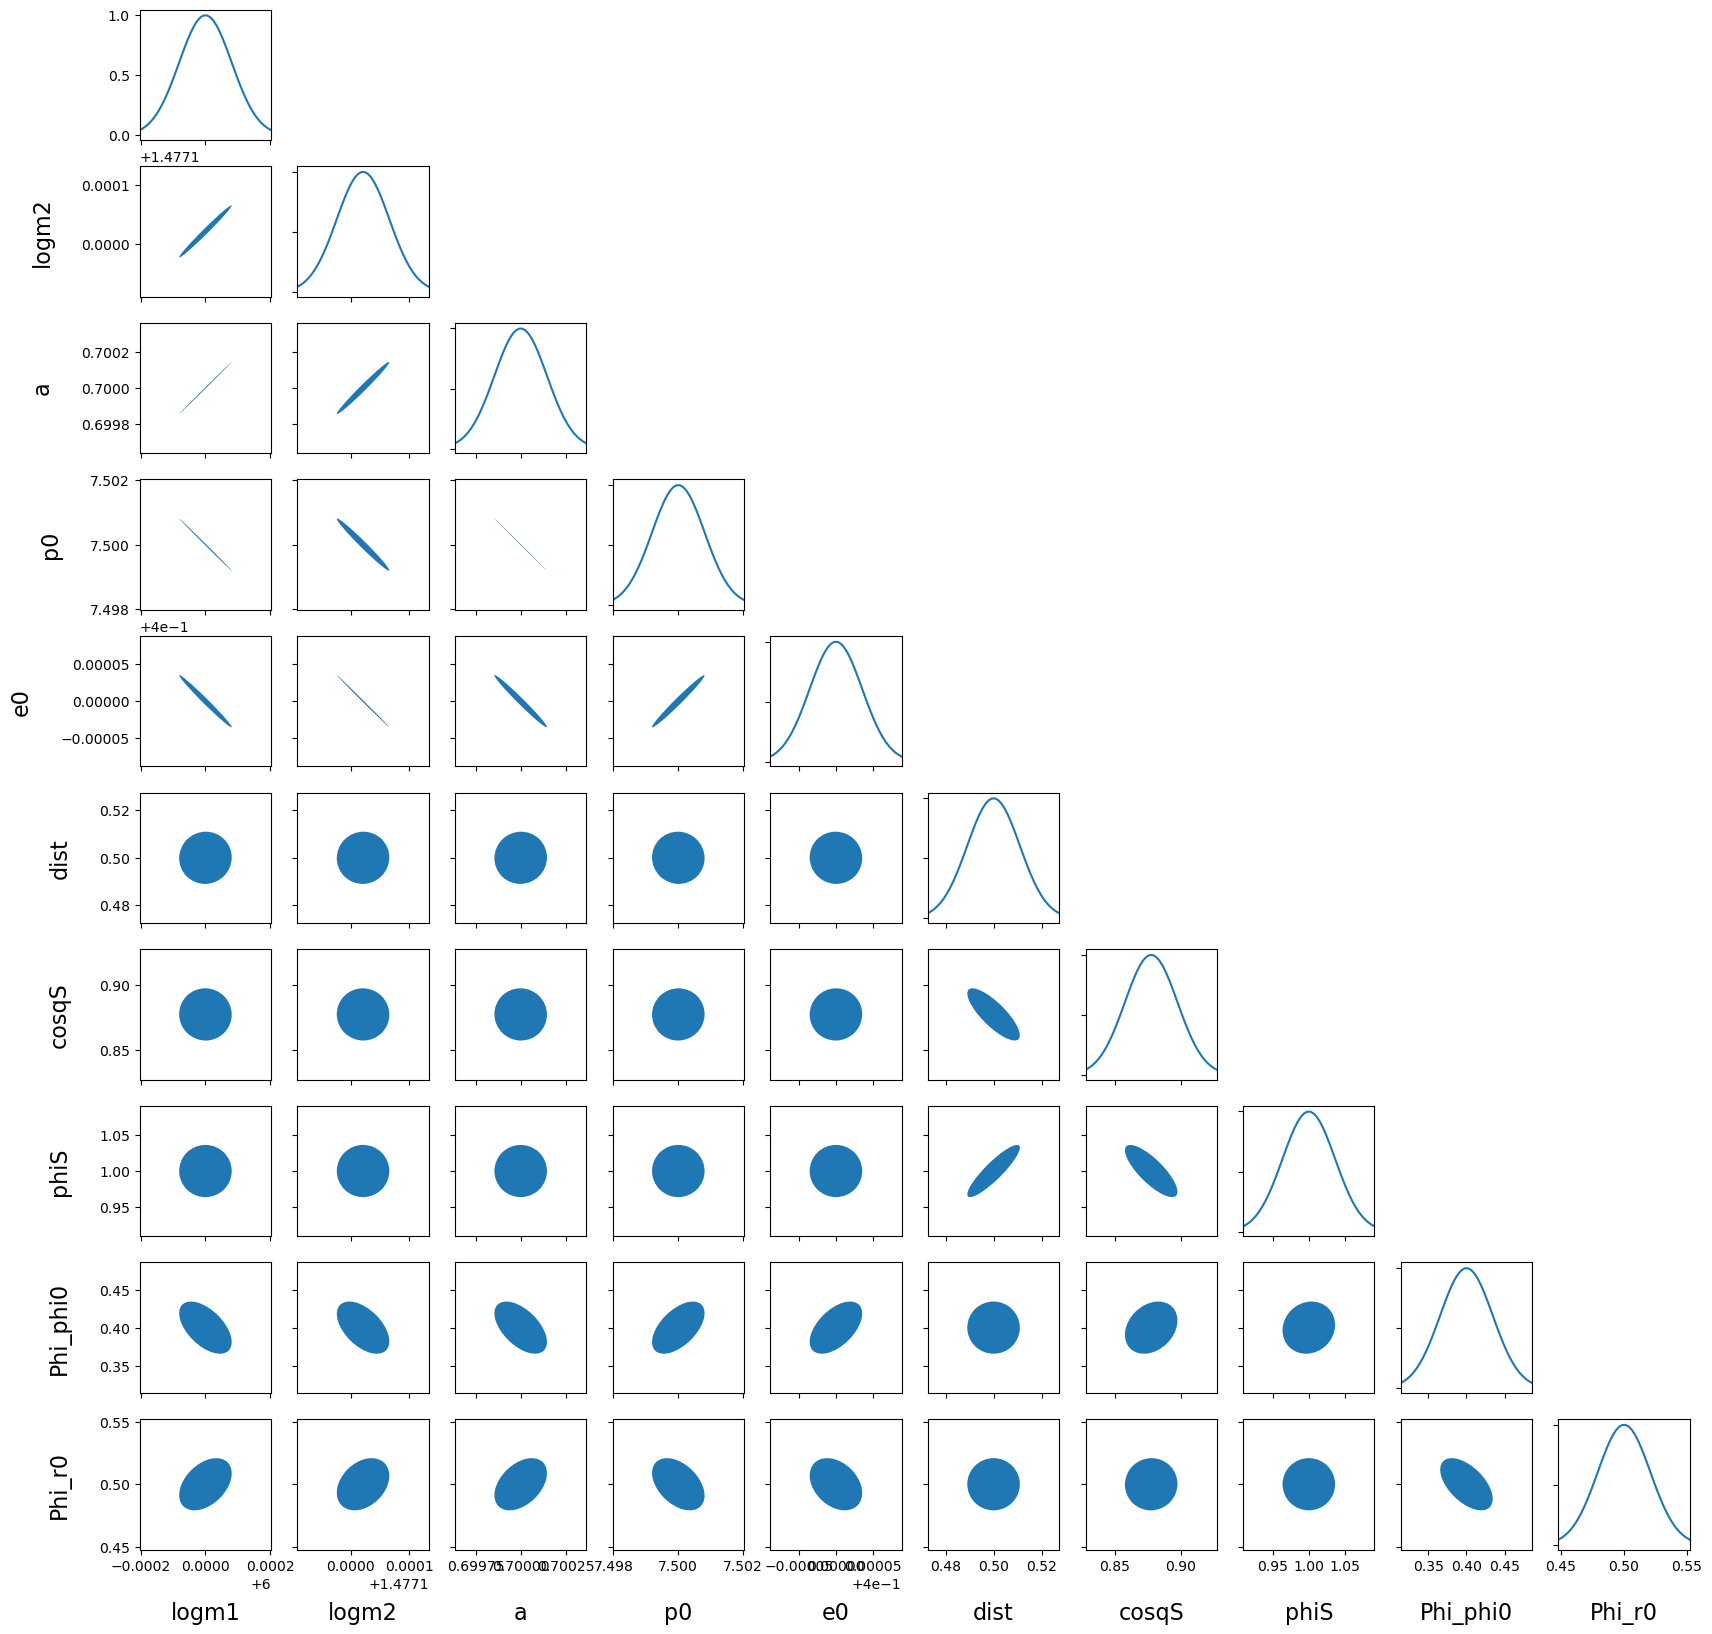

In [36]:
from stableemrifisher.plot import CovEllipsePlot

CovEllipsePlot(np.linalg.inv(Fisher), param_names=params_names, wave_params=wave_params)

In [ ]:
priors

In [ ]:
x = np.linspace(priors[2][0], priors[2][1], 50)

In [ ]:
def loglike_test(params):
    logm1, logm2, a, p0, e0, dist, cosqS, phiS, Phi_phi0, Phi_r0 = params
    m1 = 10**logm1
    m2 = 10**logm2
    qS = np.arccos(cosqS)
    phiK = phiS + np.pi/3

    htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
    

    res = data - htemp
    res_f = gwf.freq_wave(res)
    inner_res = gwf.inner(res_f, res_f)
 
    return -0.5* inner_res

In [ ]:
loglike_vals = []
for val in x:
    param = [np.log10(m1), np.log10(m2), val, p0, e0, dist, np.cos(qS), phiS, Phi_phi0, Phi_r0]
    calc_loglike = loglike_test(param)
    print(calc_loglike)
    loglike_vals.append(calc_loglike)


In [ ]:
like_vals = [np.exp(ll.get()) for ll in loglike_vals]
like_vals

In [ ]:
sigma1D = 1/np.sqrt(Fisher[2, 2])


In [ ]:
from scipy.stats import norm
normal_approx = norm.pdf(x, loc = a, scale = sigma1D)
normal_approx /= np.sum(normal_approx)
plt.plot(x, like_vals/np.sum(like_vals), c='k', label='truth')
plt.plot(x, normal_approx, c='r', label='normal approx', linestyle='--')
plt.legend()
plt.ylabel(r'$\mathcal{L}$')
# plt.xlabel(param_names[0])
# plt.savefig(f'1D_like_vs_NA_{param_names[0]}.png', dpi = 300, bbox_inches='tight')
plt.show()

In [29]:
tighter_param_ranges = [(5.999999946489075, 6.000000053510925),
 (1.477120956636667, 1.4771215528026578),
 (0.6999993767274225, 0.7000006232725774),
 (7.499999437916994, 7.500000562083006),
 (0.39999977170770384, 0.4000002282922962),
 (0.4860386493238116, 0.5139613506761884),
 (0.8702397352956238, 0.8849253884851217),
 (0.9855342921219667, 1.0144657078780333),
 (0.38728579253388856, 0.4127142074661115),
 (0.484683807978082, 0.515316192021918)]

ValueError: It looks like the provided 'range' is not valid or the sample is empty.

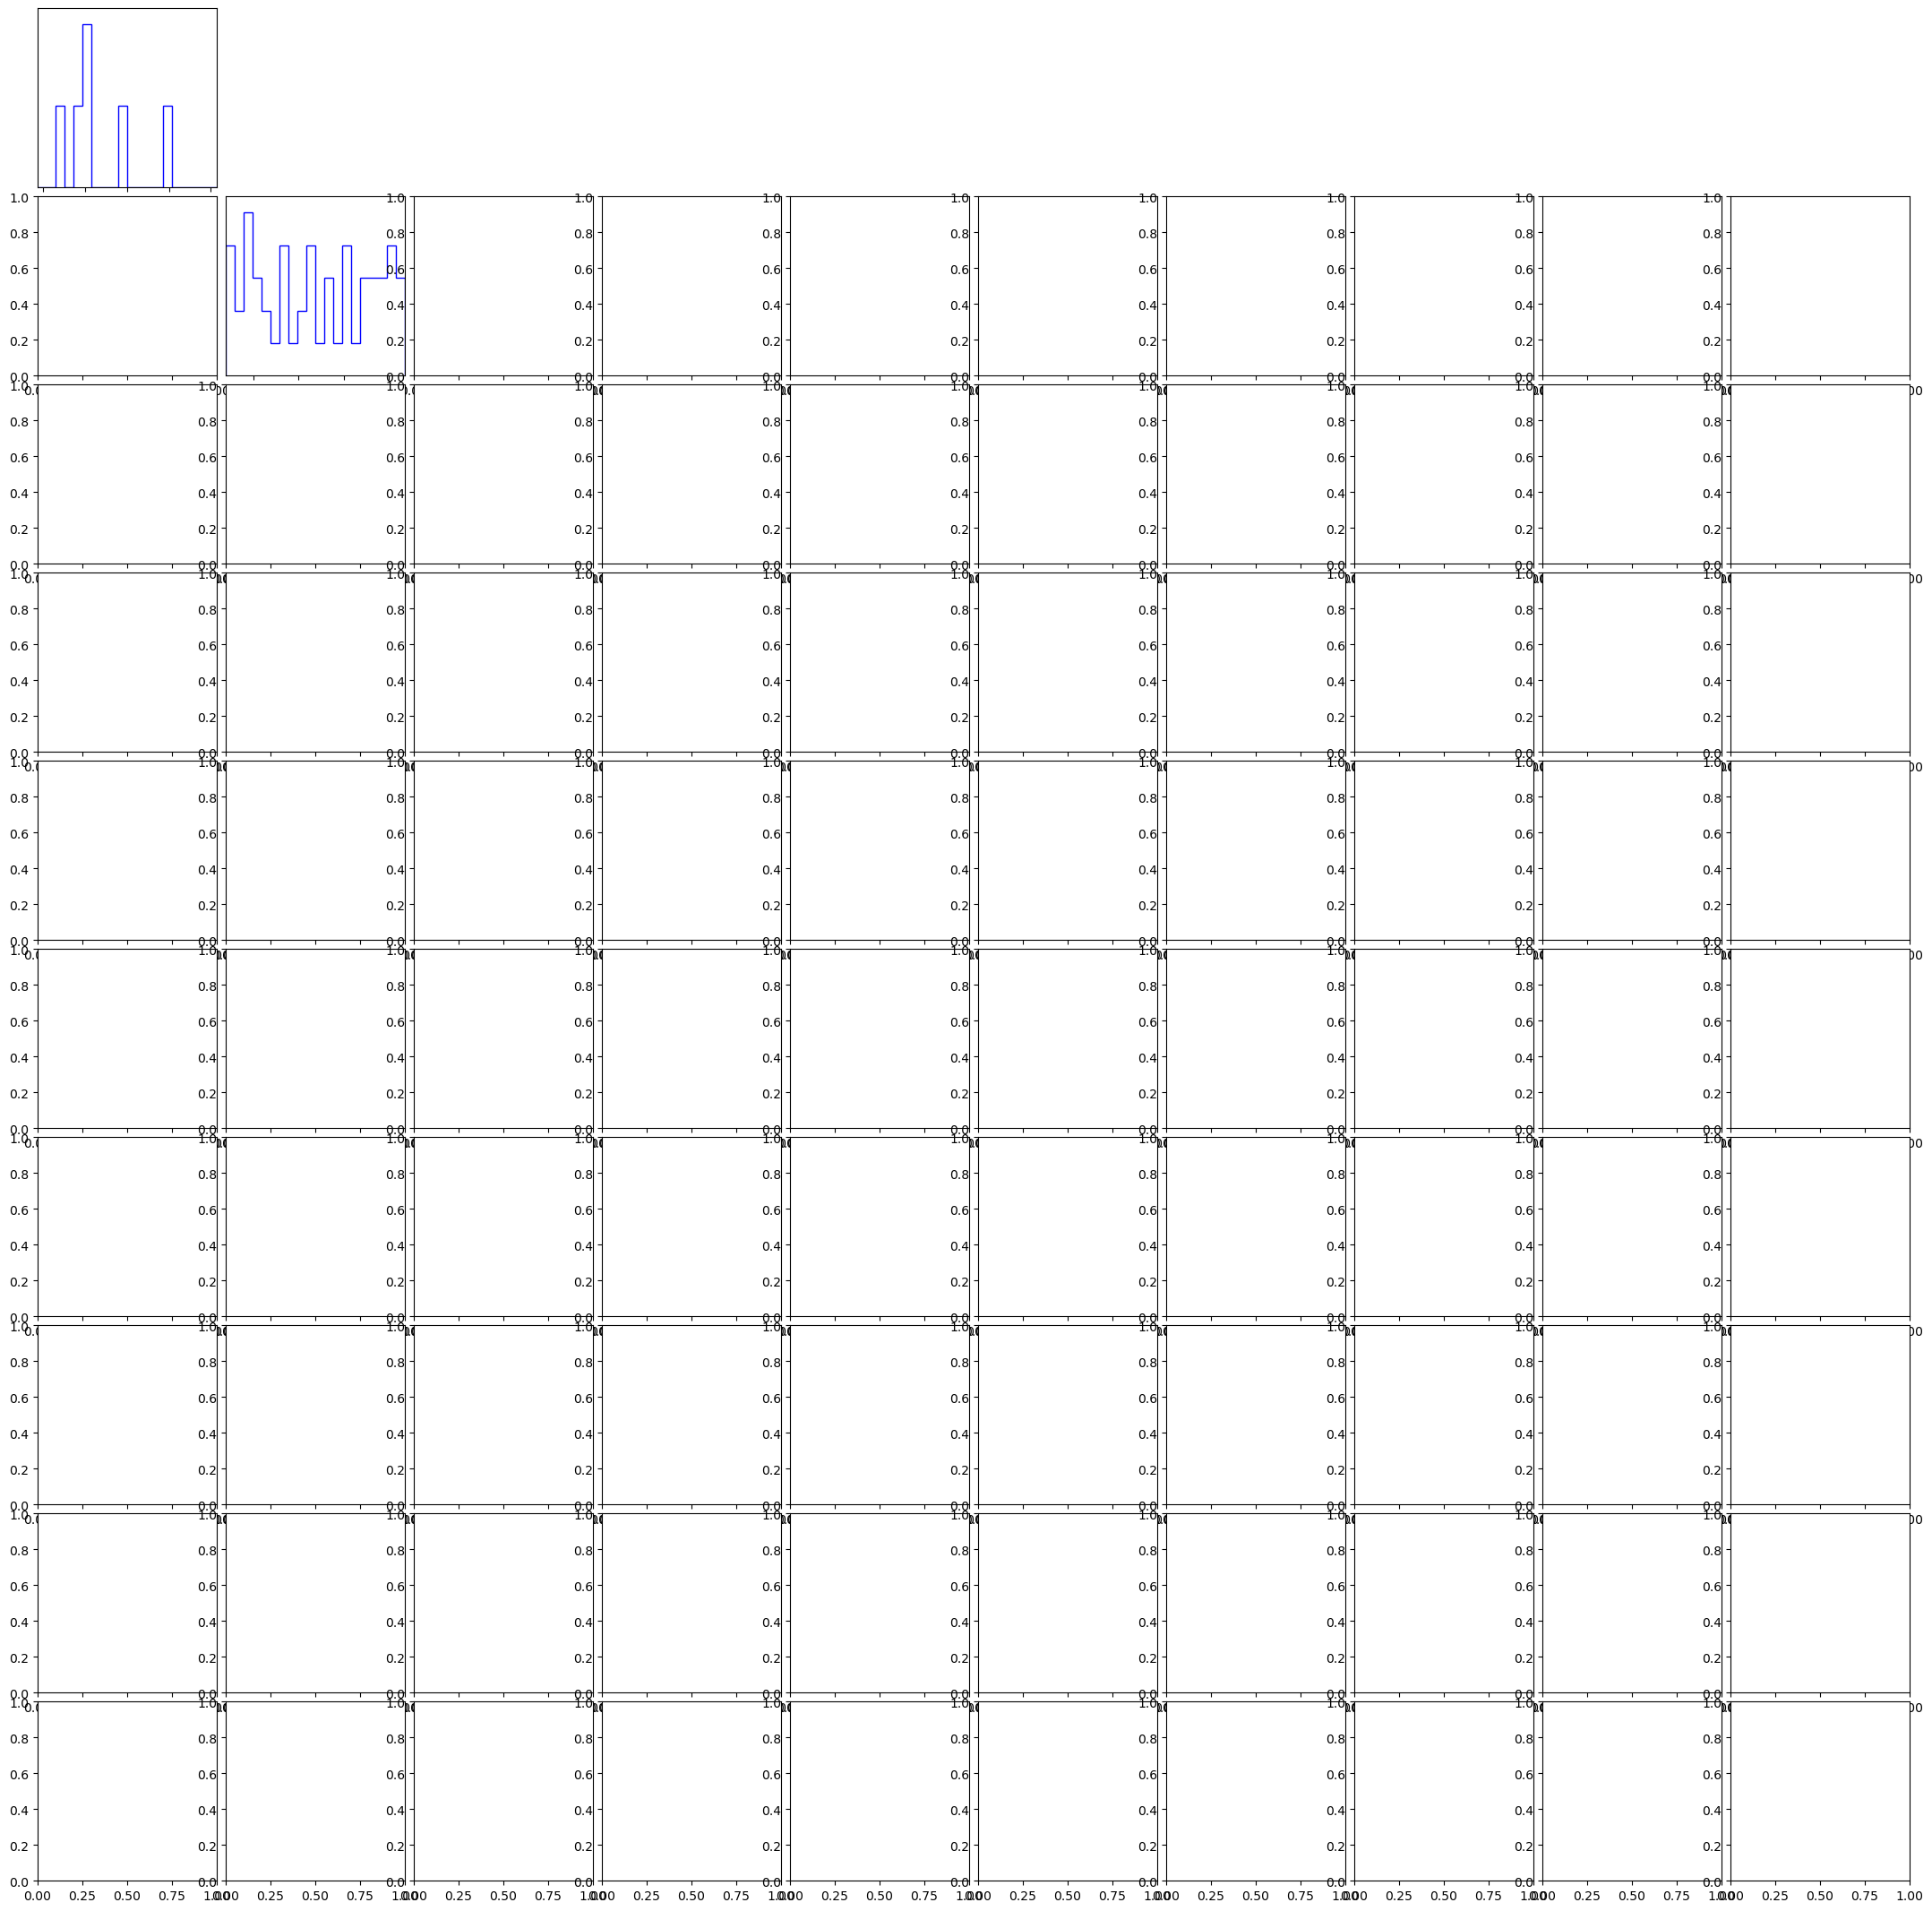

In [30]:

# Overlay Fisher ellipses
fig = corner.corner(
    fisher_samples,
    color='blue',
    plot_datapoints=False,
    plot_density=True,
    levels=[0.68, 0.95],
    alpha=0.5,
    hist_kwargs={"density": True},
    range = tighter_param_ranges
)